# Tallgrunnlag (Norge)

Vi ser på:
- Lastnivå
- Produksjon
- Variasjon over tid

# Nøkkeltall (Norge)

- Installert effekt: ~40–45 GW  
- Toppforbruk: ~25 GW  
- Normal last: 10–20 GW  
- Frekvens: 50 Hz

# Typisk døgnprofil (Norge)

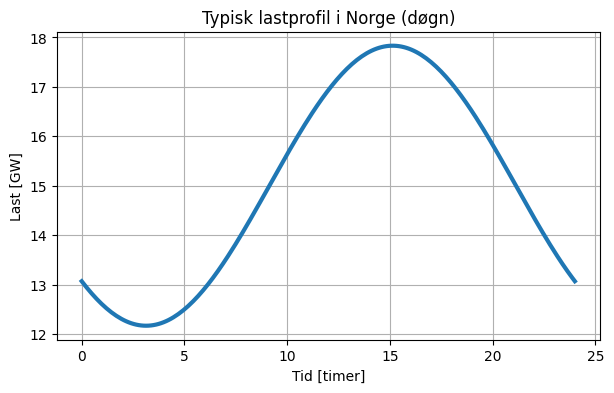

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 24, 200)
load = 15 + 5*np.sin(2*np.pi*(t-7)/24) + 3*np.sin(2*np.pi*(t-17)/24)

plt.figure(figsize=(7,4))
plt.plot(t, load, linewidth=3)
plt.xlabel("Tid [timer]")
plt.ylabel("Last [GW]")
plt.title("Typisk lastprofil i Norge (døgn)")
plt.grid(True)
plt.show()


## Hva ser vi?

- Morgenpeak rundt kl. 08  
- Kveldspeak rundt kl. 18  
- Lav last om natten  

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from IPython.display import clear_output

def power_system_demo(prod=20, inertia=5.0, damping=0.05):
    clear_output(wait=True)

    # Tid (timer)
    t = np.linspace(0, 24, 200)

    # Lastprofil
    load = 15 + 5*np.sin(2*np.pi*(t-7)/24) + 3*np.sin(2*np.pi*(t-17)/24)

    # Ubalanse
    imbalance = prod - load

    # Frekvensmodell (mer fysisk)
    # df/dt = (P_m - P_e)/(2H) - D*f
    freq = 50 + (1/(2*inertia)) * np.cumsum(imbalance*0.1) - damping * imbalance

    # --- Plot ---
    fig, axes = plt.subplots(3, 1, figsize=(8,9))

    # 1. Last vs produksjon
    axes[0].plot(t, load, linewidth=3, label="Last")
    axes[0].axhline(prod, color='r', linestyle='--', label="Produksjon")

    axes[0].set_ylabel("GW")
    axes[0].set_title("Effektbalanse")
    axes[0].legend()
    axes[0].grid(True)

    # 2. Ubalanse
    axes[1].plot(t, imbalance, linewidth=3)
    axes[1].axhline(0, linestyle='--')

    axes[1].set_ylabel("GW")
    axes[1].set_title("Ubalanse (Produksjon - Last)")
    axes[1].grid(True)

    # 3. Frekvens
    axes[2].plot(t, freq, linewidth=3)
    axes[2].axhline(50, linestyle='--', label="50 Hz")

    axes[2].set_xlabel("Tid [timer]")
    axes[2].set_ylabel("Hz")
    axes[2].set_title("Frekvensrespons")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()


interact(
    power_system_demo,
    prod=(10, 30, 0.5),       # Produksjon
    inertia=(1, 10, 0.5),     # Treghet
    damping=(0.01, 0.2, 0.01) # Demping
);


interactive(children=(FloatSlider(value=20.0, description='prod', max=30.0, min=10.0, step=0.5), FloatSlider(v…

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
from IPython.display import clear_output

def swing_demo(H=5.0, D=1.0, Pm=1.0, disturbance=-0.2):
    clear_output(wait=True)

    # Time (seconds, dynamic system!)
    dt = 0.05
    t = np.arange(0, 20, dt)

    # Nominal frequency
    f0 = 50.0

    # Electrical power (load)
    Pe = np.ones_like(t) * Pm

    # Apply disturbance at t = 5 s
    Pe[t > 5] += disturbance

    # Initialize frequency
    f = np.zeros_like(t)
    f[0] = f0

    # Numerical integration (Euler)
    for i in range(1, len(t)):
        dfdt = (1/(2*H)) * (Pm - Pe[i]) - D*(f[i-1] - f0)
        f[i] = f[i-1] + dt * dfdt

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(8,6))

    # 1. Power
    axes[0].plot(t, Pe, label="Elektrisk effekt (last)", linewidth=3)
    axes[0].axhline(Pm, linestyle='--', color='r', label="Mekanisk effekt (produksjon)")
    axes[0].set_ylabel("p.u.")
    axes[0].set_title("Effektbalanse med forstyrrelse")
    axes[0].legend()
    axes[0].grid(True)

    # 2. Frequency
    axes[1].plot(t, f, linewidth=3)
    axes[1].axhline(f0, linestyle='--', label="50 Hz")
    axes[1].set_xlabel("Tid [s]")
    axes[1].set_ylabel("Frekvens [Hz]")
    axes[1].set_title("Frekvensrespons (swing equation)")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


interact(
    swing_demo,
    H=(1, 10, 0.5),        # Inertia
    D=(0.0, 3.0, 0.1),     # Damping
    Pm=(0.8, 1.2, 0.05),   # Production
    disturbance=(-0.5, 0.5, 0.05)  # Step in load
);

interactive(children=(FloatSlider(value=5.0, description='H', max=10.0, min=1.0, step=0.5), FloatSlider(value=…